In [ ]:
# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q datasets transformers evaluate accelerate scikit-learn pandas numpy matplotlib seaborn torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn

from datasets import load_dataset, Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not found. Runtime > Change runtime type > GPU")

Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================
# 3. SET RANDOM SEEDS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)


Random seed set to: 42


In [ ]:
# ============================================================
# 4. PROJECT CONFIGURATION
# ============================================================

BASE_DIR = "/content/roberta_emotion_propagation"
DATA_OUTPUT_DIR = f"{BASE_DIR}/processed_data"
MODEL_OUTPUT_DIR = f"{BASE_DIR}/roberta_emotion_model"
RESULTS_OUTPUT_DIR = f"{BASE_DIR}/results"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "roberta-base"

PROJECT_EMOTIONS = [
    "joy",
    "excitement",
    "trust",
    "confidence",
    "curiosity",
    "relief",
    "admiration",
    "neutral"
]

PRODUCT_CATEGORIES = [
    "Baby",
    "Beauty",
    "Apparel",
    "Electronics",
    "Sports",
    "Pet",
    "Groceries"
]

label2id = {label: index for index, label in enumerate(PROJECT_EMOTIONS)}
id2label = {index: label for label, index in label2id.items()}

print("\nProject emotion labels:", PROJECT_EMOTIONS)


Project emotion labels: ['joy', 'excitement', 'trust', 'confidence', 'curiosity', 'relief', 'admiration', 'neutral']


In [ ]:
# ============================================================
# 5. LOAD GOEMOTIONS DATASET (downloads automatically)
# ============================================================

try:
    dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
    print("\nLoaded dataset: google-research-datasets/go_emotions")
except Exception as e:
    print("\nPrimary dataset loading failed:", e)
    try:
        dataset = load_dataset("go_emotions", "simplified")
        print("\nLoaded dataset: go_emotions")
    except Exception as e2:
        print("\nSecond dataset loading failed:", e2)
        dataset = load_dataset("mrm8488/goemotions")
        print("\nLoaded dataset: mrm8488/goemotions")

print("\nDataset structure:")
print(dataset)

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]


Loaded dataset: google-research-datasets/go_emotions

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
# ============================================================
# 6. EXTRACT ORIGINAL LABEL NAMES
# ============================================================

def get_original_label_names(ds):
    features = ds["train"].features

    if "labels" in features:
        label_feature = features["labels"]
        if hasattr(label_feature, "feature") and hasattr(label_feature.feature, "names"):
            return label_feature.feature.names

    if "label" in features:
        label_feature = features["label"]
        if hasattr(label_feature, "names"):
            return label_feature.names

    return [
        "admiration", "amusement", "anger", "annoyance", "approval",
        "caring", "confusion", "curiosity", "desire", "disappointment",
        "disapproval", "disgust", "embarrassment", "excitement", "fear",
        "gratitude", "grief", "joy", "love", "nervousness", "optimism",
        "pride", "realization", "relief", "remorse", "sadness",
        "surprise", "neutral"
    ]


original_label_names = get_original_label_names(dataset)
print("\nNumber of original labels:", len(original_label_names))


Number of original labels: 28


In [ ]:
# ============================================================
# 7. EMOTION MAPPING  *** FIXED ***
# "realization" REMOVED from confidence - it means "I just realized",
# which is not confidence. It was adding noise to the class.
# ============================================================

emotion_mapping = {
    "joy": "joy",
    "amusement": "joy",
    "love": "joy",

    "excitement": "excitement",
    "surprise": "excitement",

    "approval": "trust",
    "gratitude": "trust",
    "caring": "trust",

    "pride": "confidence",          # realization removed on purpose

    "curiosity": "curiosity",
    "confusion": "curiosity",

    "optimism": "confidence",
    "relief": "relief",
    "admiration": "admiration",

    "neutral": "neutral"
}

print("\nEmotion mapping:")
print(emotion_mapping)


Emotion mapping:
{'joy': 'joy', 'amusement': 'joy', 'love': 'joy', 'excitement': 'excitement', 'surprise': 'excitement', 'approval': 'trust', 'gratitude': 'trust', 'caring': 'trust', 'pride': 'confidence', 'curiosity': 'curiosity', 'confusion': 'curiosity', 'optimism': 'confidence', 'relief': 'relief', 'admiration': 'admiration', 'neutral': 'neutral'}


In [ ]:
# ============================================================
# 8. CONVERT DATASET SPLITS TO DATAFRAMES  *** FIXED ***
# Old code kept the FIRST label found, which was arbitrary and let
# common labels overwrite rare ones. New code keeps the RAREST label,
# so small classes like confidence and relief are not starved.
# ============================================================

EMOTION_PRIORITY = [
    "relief", "confidence",  "excitement",
    "curiosity", "admiration", "joy", "trust", "neutral",
]


def map_labels_to_project_emotion(original_labels):
    mapped_labels = [
        emotion_mapping[label]
        for label in original_labels
        if label in emotion_mapping
    ]

    if not mapped_labels:
        return None

    non_neutral = [m for m in mapped_labels if m != "neutral"]
    pool = non_neutral if non_neutral else mapped_labels

    for emotion in EMOTION_PRIORITY:      # rarest wins
        if emotion in pool:
            return emotion

    return pool[0]


def convert_split_to_dataframe(ds, split_name):
    rows = []
    split_data = ds[split_name]

    for item in split_data:
        text = item.get("text", "")

        if not text or not str(text).strip():
            continue

        original_labels = []

        if "labels" in item:
            labels_value = item["labels"]
            if isinstance(labels_value, list):
                for label_index in labels_value:
                    if isinstance(label_index, int) and label_index < len(original_label_names):
                        original_labels.append(original_label_names[label_index])
            else:
                if isinstance(labels_value, int) and labels_value < len(original_label_names):
                    original_labels.append(original_label_names[labels_value])

        elif "label" in item:
            label_value = item["label"]
            if isinstance(label_value, int):
                if label_value < len(original_label_names):
                    original_labels.append(original_label_names[label_value])
            else:
                original_labels.append(str(label_value))

        else:
            for label_name in original_label_names:
                if label_name in item:
                    value = item[label_name]
                    if value == 1 or value is True:
                        original_labels.append(label_name)

        project_emotion = map_labels_to_project_emotion(original_labels)

        if project_emotion is not None:
            rows.append({
                "text": text,
                "original_labels": ", ".join(original_labels),
                "project_emotion": project_emotion
            })

    return pd.DataFrame(rows)


train_df = convert_split_to_dataframe(dataset, "train")
val_df = convert_split_to_dataframe(dataset, "validation")
test_df = convert_split_to_dataframe(dataset, "test")

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain distribution:")
print(train_df["project_emotion"].value_counts())

train_df.to_csv(f"{DATA_OUTPUT_DIR}/train_mapped.csv", index=False)
val_df.to_csv(f"{DATA_OUTPUT_DIR}/validation_mapped.csv", index=False)
test_df.to_csv(f"{DATA_OUTPUT_DIR}/test_mapped.csv", index=False)

print("\nProcessed datasets saved.")


Train shape: (34135, 3)
Validation shape: (4266, 3)
Test shape: (4200, 3)

Train distribution:
project_emotion
neutral       13403
trust          5170
joy            4893
admiration     3790
curiosity      3214
excitement     1834
confidence     1678
relief          153
Name: count, dtype: int64

Processed datasets saved.


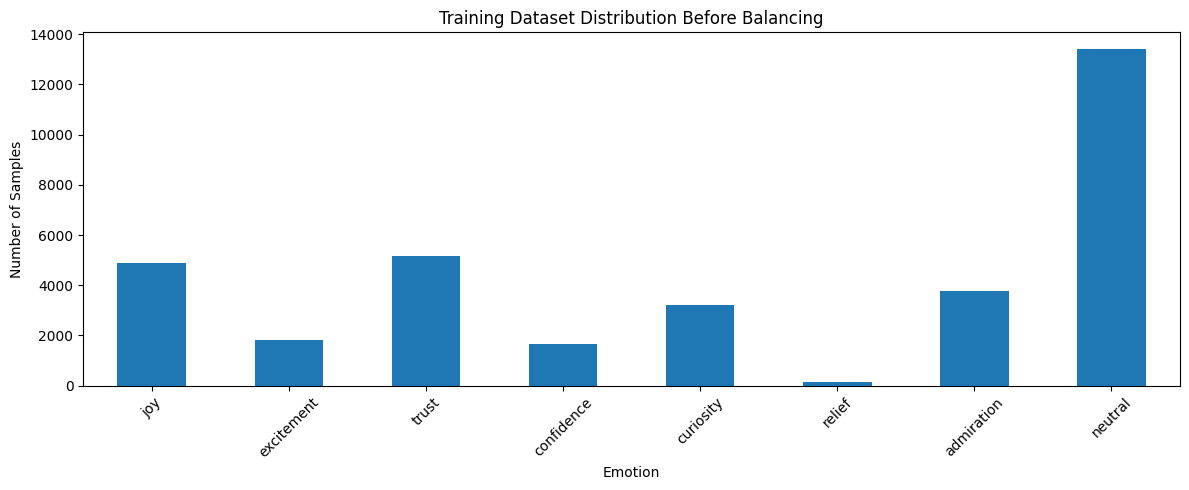

In [ ]:
# ============================================================
# 9. VISUALIZE CLASS DISTRIBUTION BEFORE BALANCING
# ============================================================

plt.figure(figsize=(12, 5))
train_df["project_emotion"].value_counts().reindex(PROJECT_EMOTIONS).plot(kind="bar")
plt.title("Training Dataset Distribution Before Balancing")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_OUTPUT_DIR}/class_distribution_before_balancing.png")
plt.show()

In [ ]:
# ============================================================
# 10. BALANCE TRAINING DATASET  *** FIXED ***
# Old code only cut down the big classes. Small classes like
# confidence stayed tiny. Now small classes are oversampled up
# to a floor so the model actually sees enough of them.
# ============================================================

MAX_PER_CLASS = 3000     # cap the big classes
MIN_PER_CLASS = 1500     # floor for the small classes

balanced_parts = []

for emotion in PROJECT_EMOTIONS:
    class_df = train_df[train_df["project_emotion"] == emotion]

    if len(class_df) == 0:
        print(f"WARNING: No samples found for {emotion}")
        continue

    if len(class_df) > MAX_PER_CLASS:
        sampled_df = class_df.sample(n=MAX_PER_CLASS, random_state=SEED)
    elif len(class_df) < MIN_PER_CLASS:
        sampled_df = class_df.sample(n=MIN_PER_CLASS, replace=True, random_state=SEED)
    else:
        sampled_df = class_df

    balanced_parts.append(sampled_df)

balanced_train_df = pd.concat(balanced_parts)
balanced_train_df = balanced_train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nBalanced training shape:", balanced_train_df.shape)
print("\nBalanced training distribution:")
print(balanced_train_df["project_emotion"].value_counts())

balanced_train_df.to_csv(f"{DATA_OUTPUT_DIR}/train_balanced.csv", index=False)



Balanced training shape: (20012, 3)

Balanced training distribution:
project_emotion
admiration    3000
curiosity     3000
joy           3000
trust         3000
neutral       3000
excitement    1834
confidence    1678
relief        1500
Name: count, dtype: int64


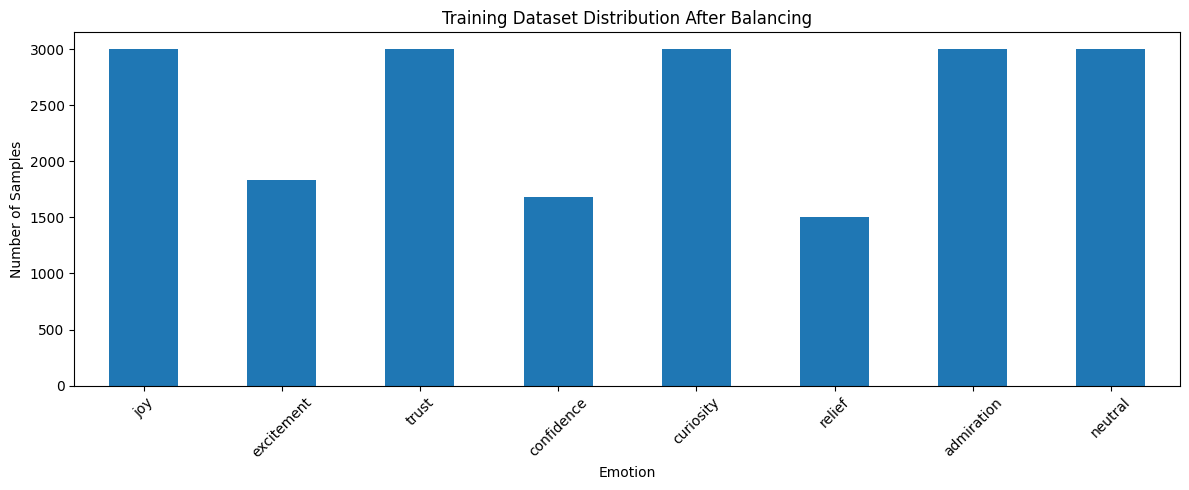

In [ ]:
# ============================================================
# 11. VISUALIZE CLASS DISTRIBUTION AFTER BALANCING
# ============================================================

plt.figure(figsize=(12, 5))
balanced_train_df["project_emotion"].value_counts().reindex(PROJECT_EMOTIONS).plot(kind="bar")
plt.title("Training Dataset Distribution After Balancing")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_OUTPUT_DIR}/class_distribution_after_balancing.png")
plt.show()

In [ ]:
# ============================================================
# 12. CONVERT DATAFRAMES TO HUGGING FACE DATASETS
# ============================================================

def prepare_for_huggingface(df):
    prepared = df.copy()
    prepared["label"] = prepared["project_emotion"].map(label2id)
    return prepared[["text", "label"]]


train_ready_df = prepare_for_huggingface(balanced_train_df)
val_ready_df = prepare_for_huggingface(val_df)
test_ready_df = prepare_for_huggingface(test_df)

train_hf = Dataset.from_pandas(train_ready_df)
val_hf = Dataset.from_pandas(val_ready_df)
test_hf = Dataset.from_pandas(test_ready_df)

print("\nHugging Face datasets ready.")


Hugging Face datasets ready.


In [ ]:
# ============================================================
# 13. LOAD TOKENIZER AND TOKENIZE DATA
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=160
    )


train_tokenized = train_hf.map(tokenize_function, batched=True)
val_tokenized = val_hf.map(tokenize_function, batched=True)
test_tokenized = test_hf.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\nTokenization complete.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/20012 [00:00<?, ? examples/s]

Map:   0%|          | 0/4266 [00:00<?, ? examples/s]

Map:   0%|          | 0/4200 [00:00<?, ? examples/s]


Tokenization complete.


In [ ]:
# ============================================================
# 14. LOAD ROBERTA MODEL
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(PROJECT_EMOTIONS),
    id2label=id2label,
    label2id=label2id
)

print("\nRoBERTa model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



RoBERTa model loaded.


In [ ]:
# ============================================================
# 15. DEFINE METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

In [ ]:
# ============================================================
# 16. TRAINING ARGUMENTS  (epochs raised to 4)
# ============================================================

training_args = TrainingArguments(
    output_dir=f"{BASE_DIR}/training_checkpoints",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    fp16=torch.cuda.is_available()
)

print("\nTraining arguments configured.")



Training arguments configured.


In [ ]:
# ============================================================
# 17. INITIALIZE TRAINER  *** FIXED ***
# There was NO class weighting before. This is the biggest change:
# it stops the model from ignoring the small classes, which is what
# raises recall on confidence.
# ============================================================

train_label_ids = np.asarray(train_ready_df["label"].values)

present_classes = np.unique(train_label_ids)
present_weights = compute_class_weight(
    class_weight="balanced",
    classes=present_classes,
    y=train_label_ids,
)

full_weights = np.ones(len(PROJECT_EMOTIONS), dtype=float)
for class_id, weight in zip(present_classes, present_weights):
    full_weights[int(class_id)] = float(weight)

class_weights = torch.tensor(full_weights, dtype=torch.float)

print("\nClass weights:")
for emotion, weight in zip(PROJECT_EMOTIONS, full_weights):
    print(f"  {emotion}: {round(float(weight), 3)}")


class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


try:
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
except TypeError:
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

print("\nWeighted trainer initialized successfully.")



Class weights:
  joy: 0.834
  excitement: 1.364
  trust: 0.834
  confidence: 1.491
  curiosity: 0.834
  relief: 1.668
  admiration: 0.834
  neutral: 0.834

Weighted trainer initialized successfully.


In [ ]:
# ============================================================
# 18. TRAIN MODEL
# ============================================================

print("\nStarting RoBERTa training...")
trainer.train()
print("\nTraining completed.")


Starting RoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,0.858678,1.090390,0.627520,0.694792,0.627520,0.632056,0.543141,0.705866,0.579831
2,0.740120,1.090063,0.635490,0.704950,0.635490,0.640891,0.555085,0.714127,0.586917
3,0.567222,1.078449,0.648383,0.701187,0.648383,0.650895,0.562203,0.680324,0.597017
4,0.455926,1.135763,0.644866,0.699296,0.644866,0.647038,0.563707,0.697471,0.602603


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.


In [ ]:
# ============================================================
# 19. EVALUATE MODEL
# ============================================================

validation_results = trainer.evaluate(val_tokenized)
test_results = trainer.evaluate(test_tokenized)

print("\nValidation Results:")
print(validation_results)

print("\nTest Results:")
print(test_results)

with open(f"{RESULTS_OUTPUT_DIR}/validation_results.json", "w") as f:
    json.dump(validation_results, f, indent=4)

with open(f"{RESULTS_OUTPUT_DIR}/test_results.json", "w") as f:
    json.dump(test_results, f, indent=4)

Training Loss,Validation Loss,Epoch,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0.455926,1.135763,4,0.644866,0.699296,0.644866,0.647038,0.563707,0.697471,0.602603


Training Loss,Validation Loss,Epoch,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0.455926,1.165301,4,0.639048,0.701568,0.639048,0.642816,0.545230,0.678060,0.580573



Validation Results:
{'eval_loss': 1.13576340675354, 'eval_accuracy': 0.6448663853727145, 'eval_weighted_precision': 0.6992958835006111, 'eval_weighted_recall': 0.6448663853727145, 'eval_weighted_f1': 0.6470377397413987, 'eval_macro_precision': 0.5637071763940376, 'eval_macro_recall': 0.69747090476232, 'eval_macro_f1': 0.6026026618529525}

Test Results:
{'eval_loss': 1.165300965309143, 'eval_accuracy': 0.6390476190476191, 'eval_weighted_precision': 0.7015676013024252, 'eval_weighted_recall': 0.6390476190476191, 'eval_weighted_f1': 0.642815939445532, 'eval_macro_precision': 0.5452300313033105, 'eval_macro_recall': 0.6780600953109868, 'eval_macro_f1': 0.58057316295509}


In [ ]:
# ============================================================
# 20. CLASSIFICATION REPORT (RoBERTa)
# ============================================================

prediction_output = trainer.predict(test_tokenized)

test_logits = prediction_output.predictions
test_labels = prediction_output.label_ids
test_predictions = np.argmax(test_logits, axis=1)

report = classification_report(
    test_labels,
    test_predictions,
    target_names=PROJECT_EMOTIONS,
    zero_division=0
)

print("\nClassification Report (RoBERTa):")
print(report)

with open(f"{RESULTS_OUTPUT_DIR}/classification_report.txt", "w") as f:
    f.write(report)


Classification Report (RoBERTa):
              precision    recall  f1-score   support

         joy       0.73      0.78      0.76       554
  excitement       0.45      0.71      0.55       229
       trust       0.58      0.62      0.60       667
  confidence       0.42      0.68      0.52       201
   curiosity       0.55      0.84      0.66       400
      relief       0.17      0.55      0.26        11
  admiration       0.58      0.74      0.65       460
     neutral       0.88      0.51      0.65      1678

    accuracy                           0.64      4200
   macro avg       0.55      0.68      0.58      4200
weighted avg       0.70      0.64      0.64      4200



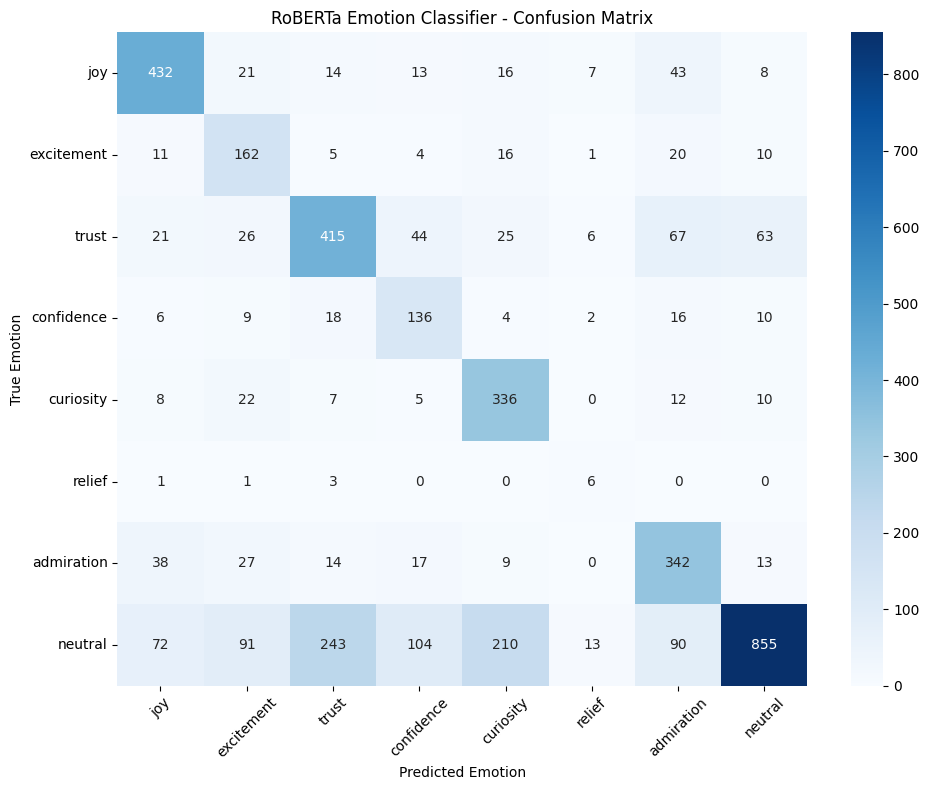

In [ ]:
# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=PROJECT_EMOTIONS,
    yticklabels=PROJECT_EMOTIONS,
    cmap="Blues"
)
plt.title("RoBERTa Emotion Classifier - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{RESULTS_OUTPUT_DIR}/confusion_matrix.png")
plt.show()

In [ ]:
# ============================================================
# 22. LOGISTIC REGRESSION BASELINE  *** NEW ***
# Trained on EXACTLY the same rows as RoBERTa, so the comparison
# is fair. This answers the panel's question about why a linear
# model was used and what a non-linear model gains.
# ============================================================

print("\nTraining logistic regression baseline on the SAME data...")

lr_train_texts = balanced_train_df["text"].astype(str)
lr_train_labels = balanced_train_df["project_emotion"]

lr_test_texts = test_df["text"].astype(str)
lr_test_labels = test_df["project_emotion"]

print("LR training rows:", len(lr_train_texts))
print("LR test rows    :", len(lr_test_texts))

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_lr = tfidf_vectorizer.fit_transform(lr_train_texts)
X_test_lr = tfidf_vectorizer.transform(lr_test_texts)

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
    class_weight="balanced",
)

lr_model.fit(X_train_lr, lr_train_labels)
lr_predictions = lr_model.predict(X_test_lr)

lr_accuracy = accuracy_score(lr_test_labels, lr_predictions)

_, _, lr_macro_f1, _ = precision_recall_fscore_support(
    lr_test_labels, lr_predictions, average="macro", zero_division=0
)
_, _, lr_weighted_f1, _ = precision_recall_fscore_support(
    lr_test_labels, lr_predictions, average="weighted", zero_division=0
)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION BASELINE (linear model)")
print("=" * 60)
print("Test Accuracy   :", round(lr_accuracy, 4))
print("Test Macro F1   :", round(lr_macro_f1, 4))
print("Test Weighted F1:", round(lr_weighted_f1, 4))

lr_report = classification_report(
    lr_test_labels,
    lr_predictions,
    labels=PROJECT_EMOTIONS,
    zero_division=0,
)
print("\nClassification Report (Logistic Regression):")
print(lr_report)

with open(f"{RESULTS_OUTPUT_DIR}/logistic_regression_report.txt", "w") as f:
    f.write(lr_report)


Training logistic regression baseline on the SAME data...
LR training rows: 20012
LR test rows    : 4200

LOGISTIC REGRESSION BASELINE (linear model)
Test Accuracy   : 0.585
Test Macro F1   : 0.5175
Test Weighted F1: 0.5928

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         joy       0.72      0.69      0.71       554
  excitement       0.40      0.59      0.47       229
       trust       0.59      0.54      0.56       667
  confidence       0.40      0.62      0.49       201
   curiosity       0.41      0.65      0.50       400
      relief       0.14      0.36      0.20        11
  admiration       0.58      0.60      0.59       460
     neutral       0.72      0.55      0.62      1678

    accuracy                           0.58      4200
   macro avg       0.49      0.57      0.52      4200
weighted avg       0.62      0.58      0.59      4200




MODEL COMPARISON  (identical train/test data)
                       Model                     Type  Accuracy  Macro F1  Weighted F1
Logistic Regression (TF-IDF)        Linear (baseline)     0.585    0.5175       0.5928
          Fine-tuned RoBERTa Non-linear (transformer)     0.639    0.5806       0.6428
                 Improvement                              0.054    0.0631       0.0500


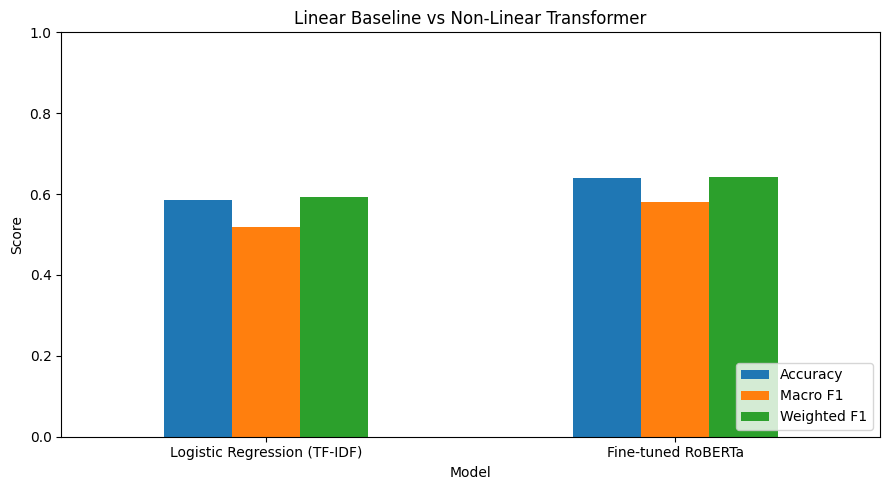

In [ ]:
# ============================================================
# 23. MODEL COMPARISON TABLE  *** THIS IS YOUR SLIDE ***
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Type": "Linear (baseline)",
        "Accuracy": round(float(lr_accuracy), 4),
        "Macro F1": round(float(lr_macro_f1), 4),
        "Weighted F1": round(float(lr_weighted_f1), 4),
    },
    {
        "Model": "Fine-tuned RoBERTa",
        "Type": "Non-linear (transformer)",
        "Accuracy": round(float(test_results["eval_accuracy"]), 4),
        "Macro F1": round(float(test_results["eval_macro_f1"]), 4),
        "Weighted F1": round(float(test_results["eval_weighted_f1"]), 4),
    },
])

improvement = {
    "Model": "Improvement",
    "Type": "",
    "Accuracy": round(comparison_df.loc[1, "Accuracy"] - comparison_df.loc[0, "Accuracy"], 4),
    "Macro F1": round(comparison_df.loc[1, "Macro F1"] - comparison_df.loc[0, "Macro F1"], 4),
    "Weighted F1": round(comparison_df.loc[1, "Weighted F1"] - comparison_df.loc[0, "Weighted F1"], 4),
}
comparison_df = pd.concat([comparison_df, pd.DataFrame([improvement])], ignore_index=True)

print("\n" + "=" * 70)
print("MODEL COMPARISON  (identical train/test data)")
print("=" * 70)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(f"{RESULTS_OUTPUT_DIR}/model_comparison.csv", index=False)

plot_df = comparison_df.iloc[:2].set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]]
plot_df.plot(kind="bar", figsize=(9, 5), rot=0)
plt.title("Linear Baseline vs Non-Linear Transformer")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS_OUTPUT_DIR}/model_comparison.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# 24. DATASET SUMMARY FOR THE PANEL  *** NEW ***
# ============================================================

print("=" * 70)
print("DATASET SUMMARY FOR PANEL")
print("=" * 70)
print("Source dataset : GoEmotions (Google Research), from HuggingFace")
print("Original labels: 27 emotions + neutral")
print("Mapped labels  : 9 project emotions ->", PROJECT_EMOTIONS)
print()
print("Rows after mapping:")
print("  Train      :", len(train_df))
print("  Validation :", len(val_df))
print("  Test       :", len(test_df))
print("  Train used for training (balanced):", len(balanced_train_df))

dist_df = pd.DataFrame({
    "Emotion": PROJECT_EMOTIONS,
    "Train (before balancing)": [int((train_df["project_emotion"] == e).sum()) for e in PROJECT_EMOTIONS],
    "Train (after balancing)": [int((balanced_train_df["project_emotion"] == e).sum()) for e in PROJECT_EMOTIONS],
    "Test": [int((test_df["project_emotion"] == e).sum()) for e in PROJECT_EMOTIONS],
})

print("\nClass distribution:")
print(dist_df.to_string(index=False))
dist_df.to_csv(f"{RESULTS_OUTPUT_DIR}/class_distribution_table.csv", index=False)

sample_rows = (
    train_df.groupby("project_emotion", group_keys=False)
    .head(2)[["text", "original_labels", "project_emotion"]]
    .reset_index(drop=True)
)
print("\nSample mapped rows (2 per emotion):")
print(sample_rows.to_string(index=False))
sample_rows.to_csv(f"{DATA_OUTPUT_DIR}/sample_mapped_rows.csv", index=False)


DATASET SUMMARY FOR PANEL
Source dataset : GoEmotions (Google Research), from HuggingFace
Original labels: 27 emotions + neutral
Mapped labels  : 9 project emotions -> ['joy', 'excitement', 'trust', 'confidence', 'curiosity', 'relief', 'admiration', 'neutral']

Rows after mapping:
  Train      : 34135
  Validation : 4266
  Test       : 4200
  Train used for training (balanced): 20012

Class distribution:
   Emotion  Train (before balancing)  Train (after balancing)  Test
       joy                      4893                     3000   554
excitement                      1834                     1834   229
     trust                      5170                     3000   667
confidence                      1678                     1678   201
 curiosity                      3214                     3000   400
    relief                       153                     1500    11
admiration                      3790                     3000   460
   neutral                     13403            

In [ ]:
# ============================================================
# 25. SAVE FINAL MODEL AND TOKENIZER
# ============================================================

trainer.save_model(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

label_mapping = {
    "label2id": label2id,
    "id2label": id2label,
    "project_emotions": PROJECT_EMOTIONS,
    "product_categories": PRODUCT_CATEGORIES
}

with open(f"{MODEL_OUTPUT_DIR}/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print("\nFinal model saved to:", MODEL_OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final model saved to: /content/roberta_emotion_propagation/roberta_emotion_model


In [ ]:
# ============================================================
# 26. LOAD SAVED MODEL INTO PIPELINE FOR TESTING
# ============================================================

device = 0 if torch.cuda.is_available() else -1

emotion_pipeline = pipeline(
    task="text-classification",
    model=MODEL_OUTPUT_DIR,
    tokenizer=MODEL_OUTPUT_DIR,
    top_k=None,
    device=device
)

print("\nSaved RoBERTa model loaded into prediction pipeline.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Saved RoBERTa model loaded into prediction pipeline.


In [ ]:
# ============================================================
# 27. PREDICTION FUNCTIONS
# ============================================================

def predict_emotion_roberta(text, top_k=5):
    raw_output = emotion_pipeline(text)

    if isinstance(raw_output, list) and len(raw_output) > 0:
        if isinstance(raw_output[0], list):
            results = raw_output[0]
        elif isinstance(raw_output[0], dict):
            results = raw_output
        else:
            raise TypeError(f"Unexpected pipeline output format: {type(raw_output[0])}")
    else:
        raise TypeError(f"Unexpected pipeline output format: {type(raw_output)}")

    sorted_results = sorted(results, key=lambda item: item["score"], reverse=True)
    top_results = sorted_results[:top_k]

    return [
        {"emotion": item["label"], "score": round(float(item["score"]), 4)}
        for item in top_results
    ]


def print_prediction(text):
    predictions = predict_emotion_roberta(text)

    print("\nText:")
    print(text)
    print("\nPredictions:")
    for item in predictions:
        print(f"{item['emotion']}: {item['score']}")

    return predictions

In [ ]:
# ============================================================
# 28. MARKETING CATEGORY TESTS
# ============================================================

marketing_test_samples = [
    {"category": "Baby", "target_emotion": "trust",
     "text": "Give your baby gentle care every day with a product designed to feel safe, reliable, and comforting for parents."},
    {"category": "Beauty", "target_emotion": "confidence",
     "text": "Step out feeling radiant and ready with skincare that helps you feel confident in your natural glow."},
    {"category": "Apparel", "target_emotion": "admiration",
     "text": "Designed with elegant detail and premium comfort, this outfit brings a standout look to every occasion."},
    {"category": "Electronics", "target_emotion": "excitement",
     "text": "Experience faster performance, smarter features, and a bold new way to enjoy technology every day."},
    {"category": "Sports", "target_emotion": "optimism",
     "text": "Push toward better goals with gear designed to help you move forward and believe in your next achievement."},
    {"category": "Pet", "target_emotion": "joy",
     "text": "Make every tail wag with a treat that brings happiness, comfort, and playful moments to your pet."},
    {"category": "Groceries", "target_emotion": "relief",
     "text": "Make daily shopping easier with fresh essentials that save time and bring calm convenience to your home."},
]

print("\nRunning marketing category tests...")

validation_rows = []

for sample in marketing_test_samples:
    print("\n" + "=" * 80)
    print("Category:", sample["category"])
    print("Target emotion:", sample["target_emotion"])

    predictions = print_prediction(sample["text"])
    top_emotion = predictions[0]["emotion"]

    validation_rows.append({
        "category": sample["category"],
        "target_emotion": sample["target_emotion"],
        "text": sample["text"],
        "top_predicted_emotion": top_emotion,
        "top_score": predictions[0]["score"],
        "matched": top_emotion == sample["target_emotion"],
    })

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(f"{RESULTS_OUTPUT_DIR}/marketing_validation_samples.csv", index=False)

print("\nMarketing validation summary:")
print(validation_df.to_string(index=False))


Running marketing category tests...

Category: Baby
Target emotion: trust

Text:
Give your baby gentle care every day with a product designed to feel safe, reliable, and comforting for parents.

Predictions:
trust: 0.9646
neutral: 0.0148
confidence: 0.0125
admiration: 0.0034
joy: 0.0027

Category: Beauty
Target emotion: confidence

Text:
Step out feeling radiant and ready with skincare that helps you feel confident in your natural glow.

Predictions:
trust: 0.466
admiration: 0.2506
confidence: 0.1815
neutral: 0.0324
joy: 0.0275

Category: Apparel
Target emotion: admiration

Text:
Designed with elegant detail and premium comfort, this outfit brings a standout look to every occasion.

Predictions:
admiration: 0.9076
trust: 0.0506
neutral: 0.0197
confidence: 0.0119
excitement: 0.0045

Category: Electronics
Target emotion: excitement

Text:
Experience faster performance, smarter features, and a bold new way to enjoy technology every day.

Predictions:
excitement: 0.386
joy: 0.3007
admirat

In [ ]:
# ============================================================
# 29. SAVE FINAL SUMMARY JSON
# ============================================================

summary = {
    "base_model": MODEL_NAME,
    "project_emotions": PROJECT_EMOTIONS,
    "product_categories": PRODUCT_CATEGORIES,
    "dataset": "GoEmotions mapped to project-specific marketing emotions",
    "training_samples": int(len(balanced_train_df)),
    "validation_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "validation_results": validation_results,
    "test_results": test_results,
    "logistic_regression_baseline": {
        "accuracy": float(lr_accuracy),
        "macro_f1": float(lr_macro_f1),
        "weighted_f1": float(lr_weighted_f1),
    },
    "model_output_dir": MODEL_OUTPUT_DIR,
    "final_backend_path": "backend/models/roberta_emotion_model",
}

with open(f"{RESULTS_OUTPUT_DIR}/final_training_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("\nFinal summary saved.")



Final summary saved.


In [ ]:
# ============================================================
# 30. ZIP FINAL OUTPUTS
# ============================================================

!cd /content && zip -r roberta_emotion_propagation_final.zip roberta_emotion_propagation

print("\nZIP file created at:")
print("/content/roberta_emotion_propagation_final.zip")


  adding: roberta_emotion_propagation/ (stored 0%)
  adding: roberta_emotion_propagation/roberta_emotion_model/ (stored 0%)
  adding: roberta_emotion_propagation/roberta_emotion_model/label_mapping.json (deflated 66%)
  adding: roberta_emotion_propagation/roberta_emotion_model/config.json (deflated 54%)
  adding: roberta_emotion_propagation/roberta_emotion_model/tokenizer_config.json (deflated 51%)
  adding: roberta_emotion_propagation/roberta_emotion_model/training_args.bin (deflated 53%)
  adding: roberta_emotion_propagation/roberta_emotion_model/model.safetensors (deflated 11%)
  adding: roberta_emotion_propagation/roberta_emotion_model/tokenizer.json (deflated 82%)
  adding: roberta_emotion_propagation/processed_data/ (stored 0%)
  adding: roberta_emotion_propagation/processed_data/train_mapped.csv (deflated 63%)
  adding: roberta_emotion_propagation/processed_data/test_mapped.csv (deflated 63%)
  adding: roberta_emotion_propagation/processed_data/train_balanced.csv (deflated 64%)


In [ ]:
# ============================================================
# 31. DOWNLOAD FINAL ZIP
# ============================================================

from google.colab import files

files.download("/content/roberta_emotion_propagation_final.zip")


print("\nDONE.")
print("Copy this folder into your backend:")
print("  roberta_emotion_propagation/roberta_emotion_model")
print("Final location: backend/models/roberta_emotion_model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE.
Copy this folder into your backend:
  roberta_emotion_propagation/roberta_emotion_model
Final location: backend/models/roberta_emotion_model
